In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from google.colab import files
uploaded = files.upload()
Uploaded2 = files.upload()

Saving fin_by_edu.csv to fin_by_edu.csv


Saving SCFP2022.csv to SCFP2022 (2).csv


In [23]:
df = pd.read_csv("fin_by_edu.csv")
#VALUES IN THOUSANDS (1000s)

base = pd.read_csv("SCFP2022.csv")

In [13]:
edu = df[df["year"]>= 2001].copy()

edu["Estimated_Home_Equity"] = (edu["Primary_Residence"] - edu["Home_Secured_Debt"])

edu["Estimated_Home_Equity_Ratio"] = (edu["Estimated_Home_Equity"] / edu["Primary_Residence"])

edu["Edu_Debt_to_Income"] = (edu["Education_Installment_Loans"] / edu["Before_Tax_Income"])

edu["Edu_Debt_to_Assets"] = (edu["Education_Installment_Loans"] / edu["Assets"])

edu["Edu_Debt_to_House"] = (edu["Education_Installment_Loans"] / edu["Primary_Residence"])

edu["Debt_to_Income"] = (edu["Debt"] / edu["Before_Tax_Income"])

edu["Home_Debt_to_Income"] = (edu["Home_Secured_Debt"] / edu["Before_Tax_Income"])

edu = edu.round(2)

edu

,year,Category,Before_Tax_Income,Net_Worth,Assets,Financial_Assets,Transaction_Accounts,Certificates_of_Deposit,Savings_Bonds,Directly_Held_Bonds,...,Vehicle_Installment_Loans,Education_Installment_Loans,Other_Installment_Loans,Estimated_Home_Equity,Estimated_Home_Equity_Ratio,Edu_Debt_to_Income,Edu_Debt_to_Assets,Edu_Debt_to_House,Debt_to_Income,Home_Debt_to_Income
16,2001,No high school diploma,27.55,42.54,108.81,7.37,2.51,25.11,0.67,75.33,...,13.56,4.52,3.01,75.33,0.60,0.16,0.04,0.04,0.73,1.82
17,2001,High school diploma,56.82,97.10,176.46,23.34,4.19,26.79,1.14,36.83,...,13.39,9.71,2.85,70.31,0.44,0.17,0.06,0.06,0.75,1.56
18,2001,Some college,68.87,138.86,248.10,39.42,5.27,18.41,2.01,98.77,...,16.41,9.21,4.02,92.07,0.44,0.13,0.04,0.04,0.90,1.70
19,2001,College degree,122.25,406.31,580.40,171.26,14.75,25.11,2.51,83.70,...,16.74,20.93,5.36,154.01,0.48,0.17,0.04,0.07,1.17,1.34
20,2004,No high school diploma,30.65,32.37,78.12,3.46,1.73,23.57,0.79,97.42,...,13.67,7.86,2.69,48.71,0.41,0.26,0.10,0.07,0.62,2.26
21,2004,High school diploma,56.46,107.48,208.98,18.86,3.96,26.71,0.94,31.43,...,14.46,7.86,3.14,86.42,0.44,0.14,0.04,0.04,0.86,1.95
22,2004,Some college,69.37,124.32,252.19,31.43,4.71,17.28,1.57,62.85,...,17.28,10.68,4.24,109.99,0.44,0.15,0.04,0.04,1.17,1.99
23,2004,College degree,124.22,423.62,664.81,146.21,15.71,28.28,1.57,128.84,...,20.43,23.57,7.38,186.98,0.48,0.19,0.04,0.06,1.48,1.66
24,2007,No high school diploma,32.38,47.37,92.59,4.22,1.73,20.03,1.43,812.81,...,14.31,8.59,2.86,104.46,0.59,0.27,0.09,0.05,0.85,2.21
25,2007,High school diploma,52.98,115.20,231.11,20.32,3.58,22.90,1.43,65.83,...,15.74,8.87,3.58,94.45,0.44,0.17,0.04,0.04,1.08,2.27


In [14]:
college = edu[edu["Category"] == "College degree"]
some = edu[edu["Category"] == "Some college"]
hs = edu[edu["Category"] == "High school diploma"]
nhs = edu[edu["Category"] == "No high school diploma"]

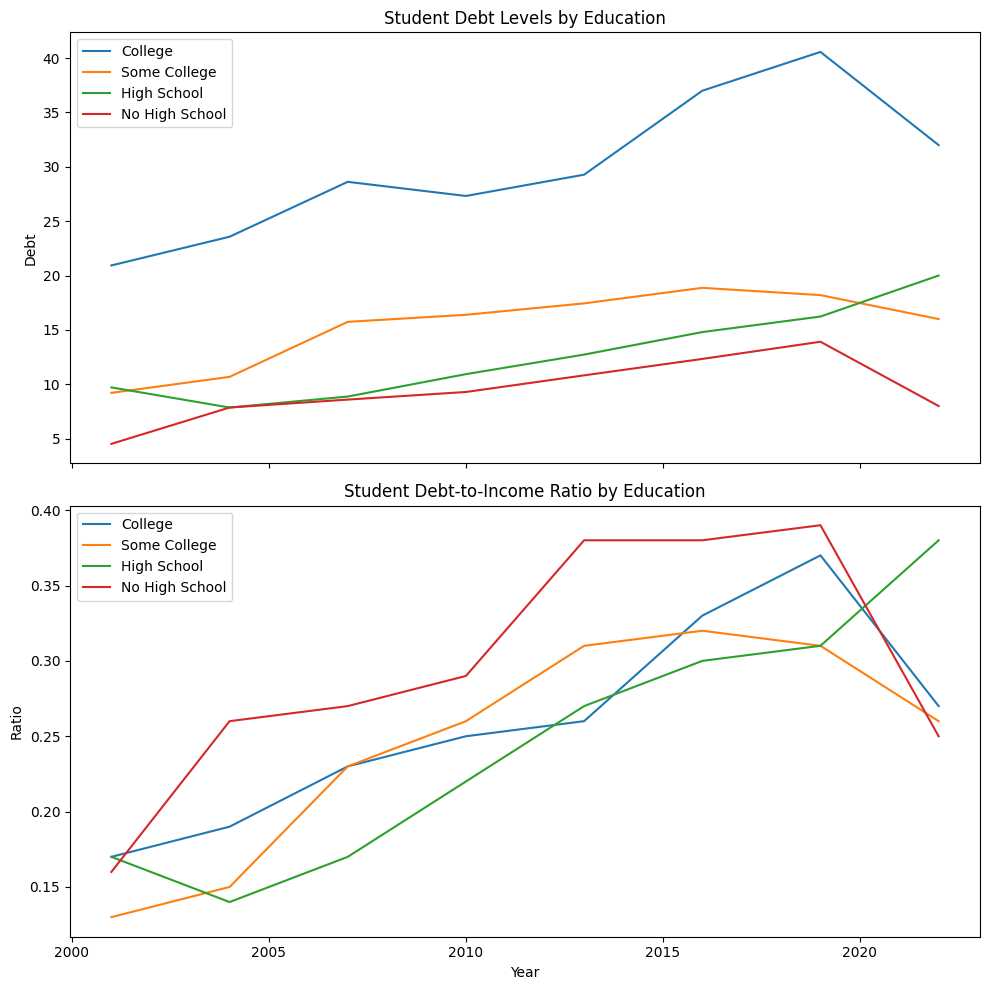

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Student Debt
ax[0].plot(college["year"], college["Education_Installment_Loans"], label="College")
ax[0].plot(some["year"], some["Education_Installment_Loans"], label="Some College")
ax[0].plot(hs["year"], hs["Education_Installment_Loans"], label="High School")
ax[0].plot(nhs["year"], nhs["Education_Installment_Loans"], label="No High School")

ax[0].set_title("Student Debt Levels by Education")
ax[0].set_ylabel("Debt")
ax[0].legend()

# Student Debt Burden
ax[1].plot(college["year"], college["Edu_Debt_to_Income"], label="College")
ax[1].plot(some["year"], some["Edu_Debt_to_Income"], label="Some College")
ax[1].plot(hs["year"], hs["Edu_Debt_to_Income"], label="High School")
ax[1].plot(nhs["year"], nhs["Edu_Debt_to_Income"], label="No High School")

ax[1].set_title("Student Debt-to-Income Ratio by Education")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Ratio")
ax[1].legend()

plt.tight_layout()
plt.show()

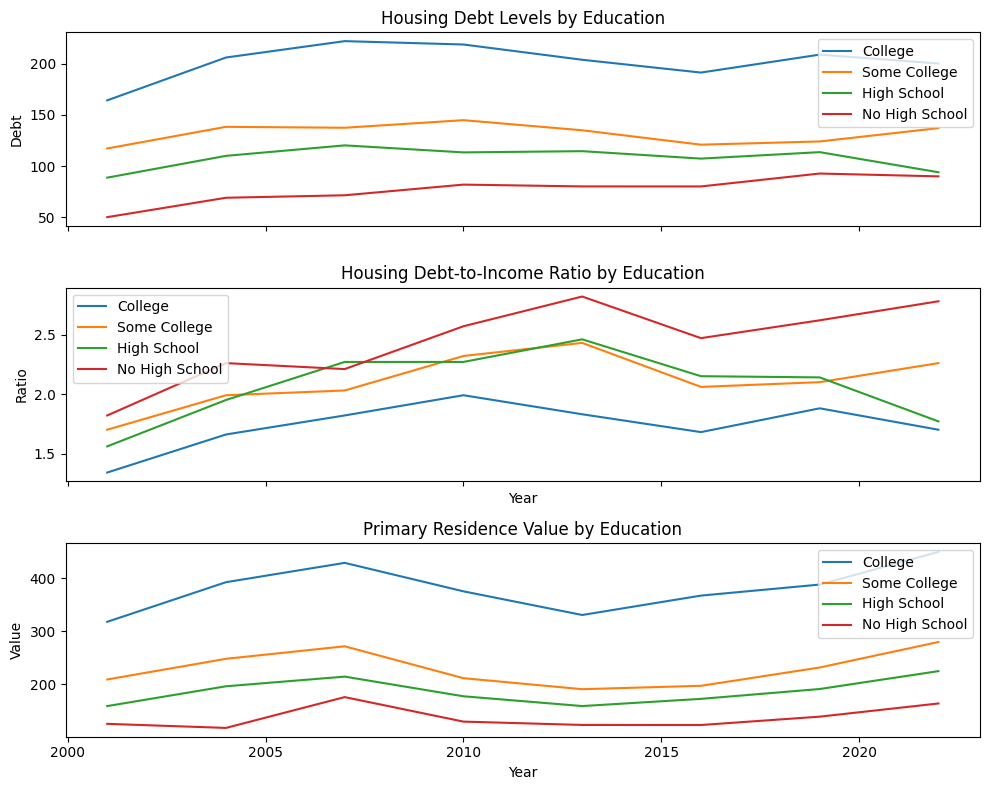

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Housing Debt Levels
ax[0].plot(college["year"], college["Home_Secured_Debt"], label="College")
ax[0].plot(some["year"], some["Home_Secured_Debt"], label="Some College")
ax[0].plot(hs["year"], hs["Home_Secured_Debt"], label="High School")
ax[0].plot(nhs["year"], nhs["Home_Secured_Debt"], label="No High School")

ax[0].set_title("Housing Debt Levels by Education")
ax[0].set_ylabel("Debt")
ax[0].legend()

# Housing Debt Burden
ax[1].plot(college["year"], college["Home_Debt_to_Income"], label="College")
ax[1].plot(some["year"], some["Home_Debt_to_Income"], label="Some College")
ax[1].plot(hs["year"], hs["Home_Debt_to_Income"], label="High School")
ax[1].plot(nhs["year"], nhs["Home_Debt_to_Income"], label="No High School")

ax[1].set_title("Housing Debt-to-Income Ratio by Education")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Ratio")
ax[1].legend()

# Primary Residence Value
ax[2].plot(college["year"], college["Primary_Residence"], label="College")
ax[2].plot(some["year"], some["Primary_Residence"], label="Some College")
ax[2].plot(hs["year"], hs["Primary_Residence"], label="High School")
ax[2].plot(nhs["year"], nhs["Primary_Residence"], label="No High School")

ax[2].set_title("Primary Residence Value by Education")
ax[2].set_xlabel("Year")
ax[2].set_ylabel("Value")
ax[2].legend()

plt.tight_layout()
plt.show()

plt.show()

In [17]:
surv = base.copy()
surv = surv.groupby('YY1').mean().reset_index()
surv = surv[(surv['HOUSES'] > 0) & (surv['INCOME'] > 0)]

surv['log_HOUSES'] = np.log(surv['HOUSES'])
surv['log_INCOME'] = np.log(surv['INCOME'])


surv['EDNM'] = surv['EDCL'].map({
    1: 'No High School',
    2: 'High School',
    3: 'Some College',
    4: 'College'
})


surv = surv[surv['EDNM'].isin(['High School', 'Some College', 'College'])].copy()
print(surv['EDNM'].value_counts())

surv_debt = surv[surv['EDN_INST'] > 0].copy()
surv_debt['log_EDN'] = np.log(surv_debt['EDN_INST'])
print(surv_debt['EDNM'].value_counts())

surv['log_EDN'] = np.log(surv['EDN_INST']+1)


EDNM
College         1804
Some College     585
High School      506
Name: count, dtype: int64
EDNM
College         260
Some College     92
High School      48
Name: count, dtype: int64


In [18]:
#PRIMARY ANALYSIS - FULL SAMPLE, FILTERED HOUSE VALUE AND INCOME > 0

model = smf.ols(
    'log_HOUSES ~ (log_INCOME + log_EDN) * C(EDNM)',
    data=surv
).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_HOUSES   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     390.2
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:26:28   Log-Likelihood:                -3439.0
No. Observations:                2895   AIC:                             6896.
Df Residuals:                    2886   BIC:                             6950.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [19]:
#SECONDARY ANALYSIS - DEBT ONLY SAMPLE, FILTERED HOUSE VALUE, INCOME AND STUDENT DEBT > 0

debt_model = smf.ols(
    'log_HOUSES ~ (log_INCOME + log_EDN) * C(EDNM)',
    data=surv_debt
).fit(cov_type='HC3')

print(debt_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_HOUSES   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     25.60
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           9.23e-32
Time:                        21:26:30   Log-Likelihood:                -431.00
No. Observations:                 400   AIC:                             880.0
Df Residuals:                     391   BIC:                             915.9
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

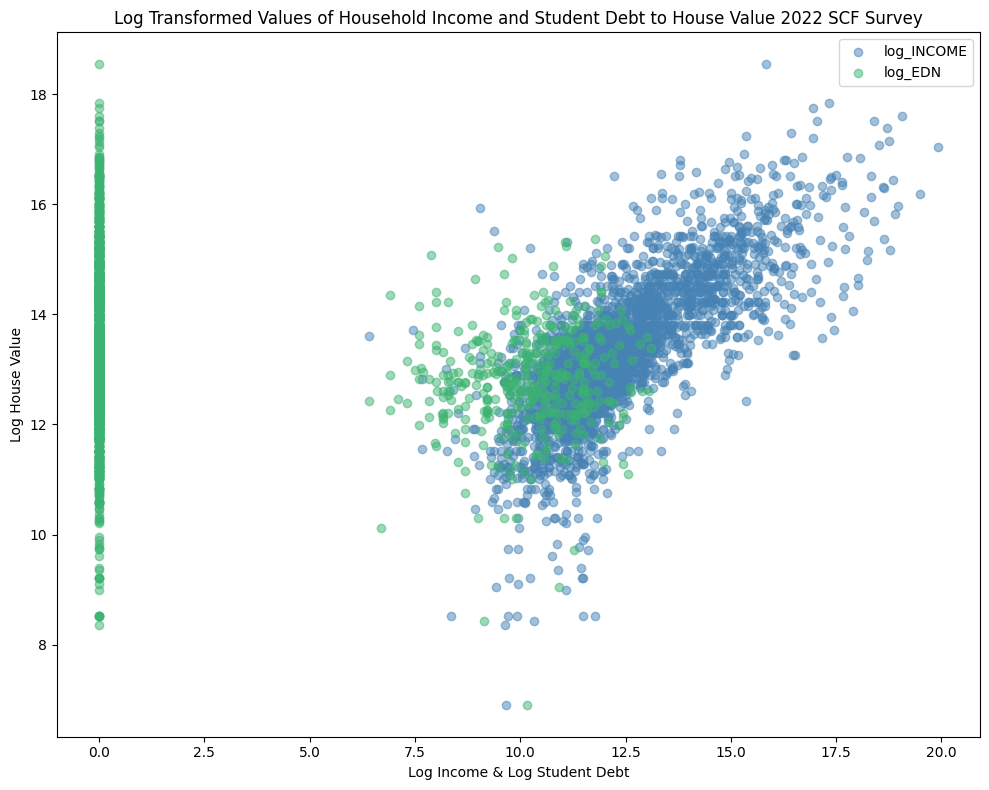

In [20]:
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

# Plot 1: Log scale - all 3 metrics vs log_HOUSES
axes.scatter(surv['log_INCOME'], surv['log_HOUSES'], alpha=0.5, color='steelblue', label='log_INCOME')
axes.scatter(surv['log_EDN'], surv['log_HOUSES'], alpha=0.5, color='mediumseagreen', label='log_EDN')
axes.set_xlabel('Log Income & Log Student Debt')
axes.set_ylabel('Log House Value')
axes.set_title('Log Transformed Values of Household Income and Student Debt to House Value 2022 SCF Survey')
axes.legend()

plt.tight_layout()
plt.show()

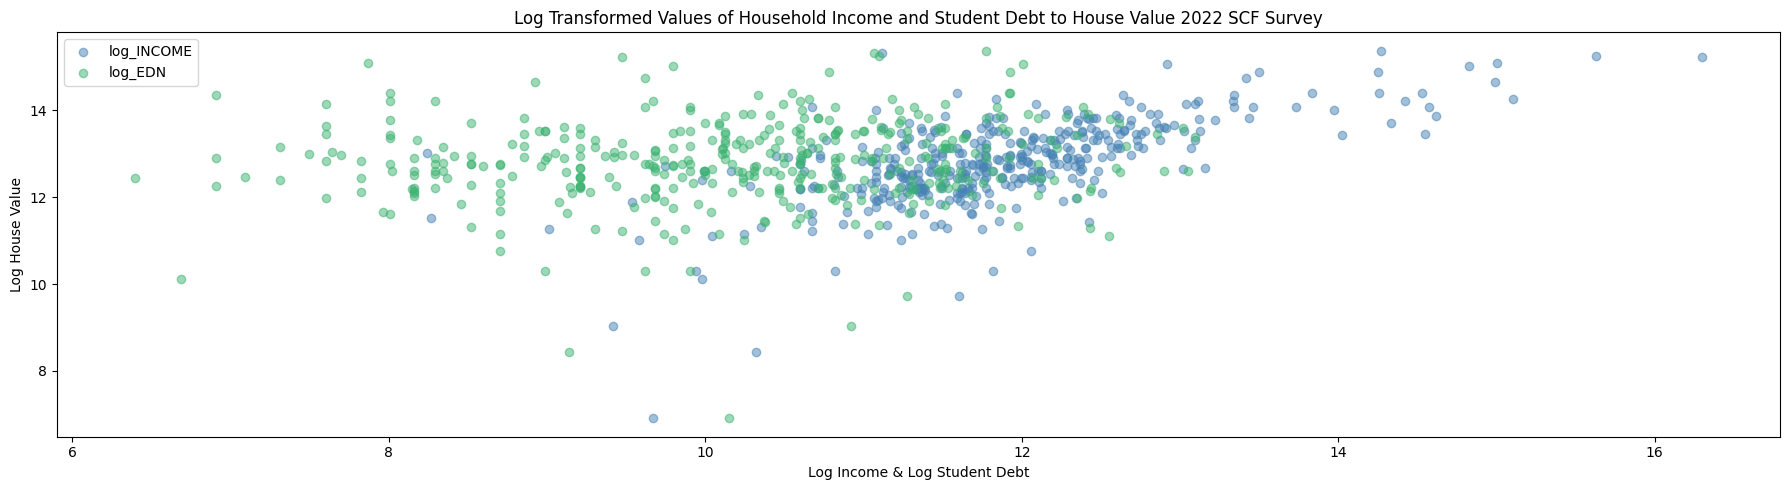

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

# Plot 1: Log scale - all 3 metrics vs log_HOUSES
axes.scatter(surv_debt['log_INCOME'], surv_debt['log_HOUSES'], alpha=0.5, color='steelblue', label='log_INCOME')
axes.scatter(surv_debt['log_EDN'], surv_debt['log_HOUSES'], alpha=0.5, color='mediumseagreen', label='log_EDN')
axes.set_xlabel('Log Income & Log Student Debt')
axes.set_ylabel('Log House Value')
axes.set_title('Log Transformed Values of Household Income and Student Debt to House Value 2022 SCF Survey')
axes.legend()

plt.tight_layout()
plt.show()